In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
%matplotlib inline 
sns.set(style="ticks")

## Загрузка и первичный анализ данных

In [2]:
data = pd.read_csv('pizza_sales.csv', sep=",")

In [3]:
# размер набора данных
data.shape

(48620, 12)

In [4]:
# типы колонок
data.dtypes

pizza_id             float64
order_id             float64
pizza_name_id         object
quantity             float64
order_date            object
order_time            object
unit_price           float64
total_price          float64
pizza_size            object
pizza_category        object
pizza_ingredients     object
pizza_name            object
dtype: object

In [5]:
# проверим есть ли пропущенные значения
data.isnull().sum()

pizza_id             0
order_id             0
pizza_name_id        0
quantity             0
order_date           0
order_time           0
unit_price           0
total_price          0
pizza_size           0
pizza_category       0
pizza_ingredients    0
pizza_name           0
dtype: int64

In [6]:
# Первые 5 строк датасета
data.head()

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1.0,1.0,hawaiian_m,1.0,1/1/2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2.0,2.0,classic_dlx_m,1.0,1/1/2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3.0,2.0,five_cheese_l,1.0,1/1/2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4.0,2.0,ital_supr_l,1.0,1/1/2015,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5.0,2.0,mexicana_m,1.0,1/1/2015,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [7]:
total_count = data.shape[0]
print('Всего строк: {}'.format(total_count))

Всего строк: 48620


## Визуализация временного ряда

In [8]:
data['order_date_clean'] = data['order_date'].str.replace('-', '/')
data['Date'] = pd.to_datetime(data['order_date'], format='mixed', dayfirst=True)
year = 2015
ts_fb = data[data['Date'].dt.year == year]
ts_fb = ts_fb.groupby('Date')['total_price'].mean()
ts_fb = ts_fb.sort_index()

In [9]:
ts_fb.head()

Date
2015-01-01    16.856211
2015-01-02    17.074375
2015-01-03    17.288312
2015-01-04    16.560849
2015-01-05    17.073967
Name: total_price, dtype: float64

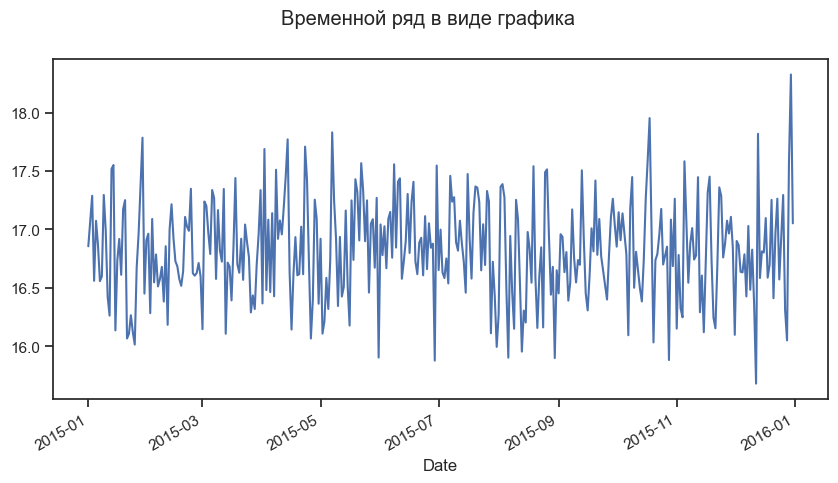

In [10]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Временной ряд в виде графика')
ts_fb.plot(ax=ax, legend=False)
pyplot.show()

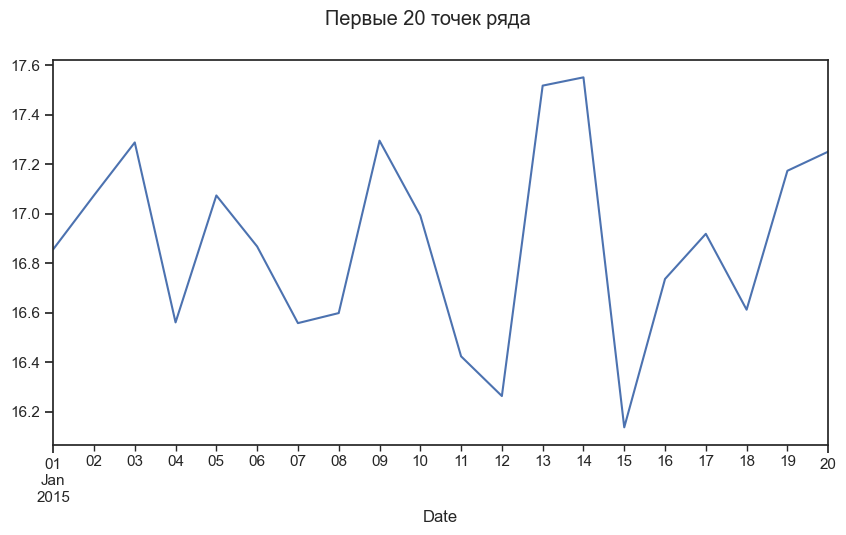

In [11]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Первые 20 точек ряда')
ts_fb[:20].plot(ax=ax, legend=False)
pyplot.show()

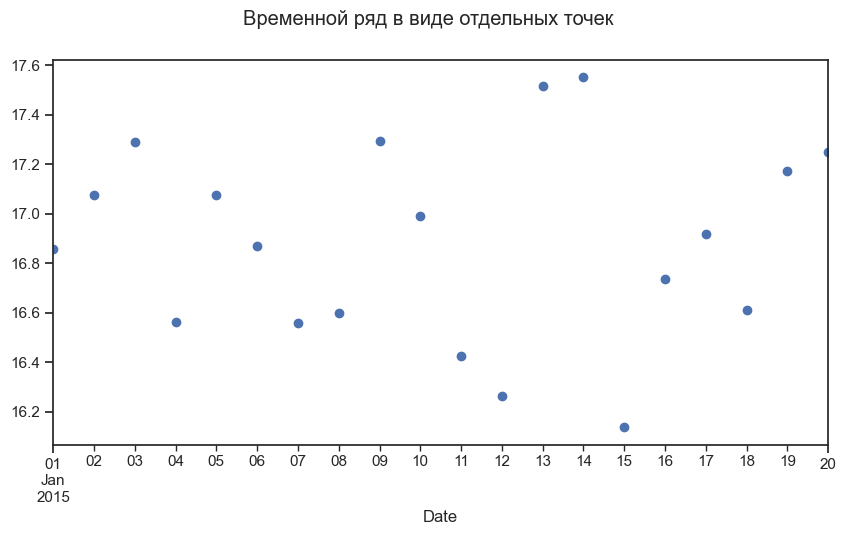

In [12]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Временной ряд в виде отдельных точек')
ts_fb[:20].plot(ax=ax, legend=False, style='bo')
pyplot.show()

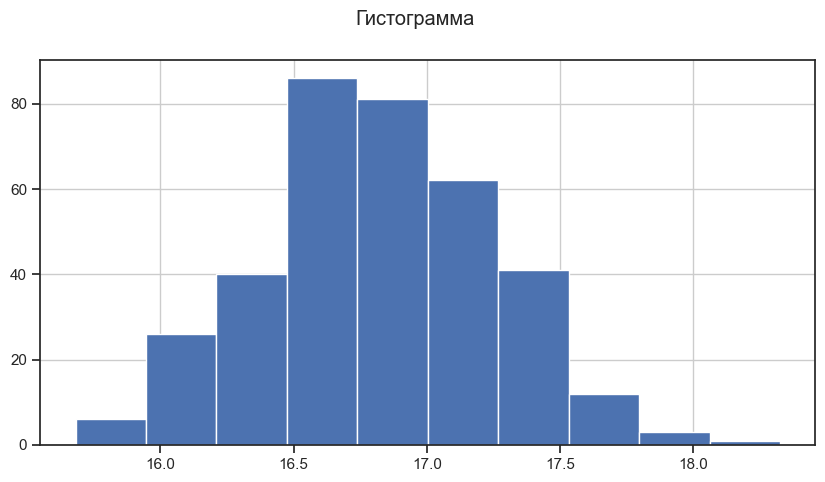

In [13]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Гистограмма')
ts_fb.hist(ax=ax, legend=False)
pyplot.show()

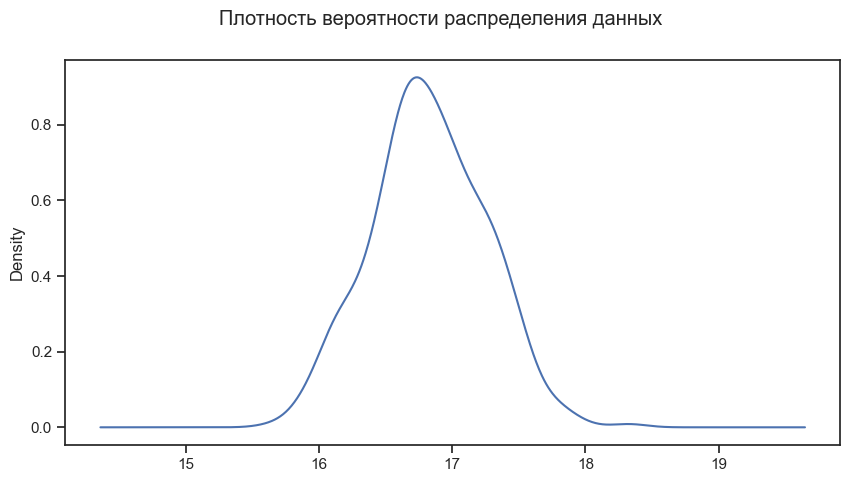

In [14]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Плотность вероятности распределения данных')
ts_fb.plot(ax=ax, kind='kde', legend=False)
pyplot.show()

## Разделение временного ряда на обучающую и тестовую выборки

In [15]:
test_size = 70

train = ts_fb[:-test_size]

test = ts_fb[-test_size:]

print(f"Размер обучающей выборки: {len(train)}")
print(f"Размер тестовой выборки: {len(test)}")

Размер обучающей выборки: 288
Размер тестовой выборки: 70


## Прогнозирование временного ряда

### 1) Метод ARIMA

In [16]:
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [17]:
# Если ts_fb это Series, преобразуем в DataFrame для удобства
ts_fb2 = pd.DataFrame(ts_fb)
ts_fb2.columns = ['AveragePrice']  # или 'total_price' для пиццы
ts_fb2 = ts_fb2.reset_index()
ts_fb2.columns = ['Date', 'AveragePrice']

In [18]:
# Целочисленная метка шкалы времени 
xnum = list(range(ts_fb2.shape[0]))
# Разделение выборки на обучающую и тестовую (70% train, 30% test)
Y = ts_fb2['AveragePrice'].values
train_size = int(len(Y) * 0.7)
xnum_train, xnum_test = xnum[0:train_size], xnum[train_size:]
train, test = Y[0:train_size], Y[train_size:]
history_arima = [x for x in train]
history_es = [x for x in train]

In [19]:
# Параметры модели (p,d,q)
arima_order = (5, 1, 0)
# Формирование предсказаний ARIMA
predictions_arima = list()
for t in range(len(test)):
    model_arima = ARIMA(history_arima, order=arima_order)
    model_arima_fit = model_arima.fit()
    yhat_arima = model_arima_fit.forecast()[0]
    predictions_arima.append(yhat_arima)
    history_arima.append(test[t])
# Вычисление метрики RMSE для ARIMA
error_arima = mean_squared_error(test, predictions_arima, squared=False)

In [20]:
# Формирование предсказаний Exponential Smoothing (Хольта-Винтерса)
predictions_es = list()
for t in range(len(test)):
    model_es = ExponentialSmoothing(history_es)
    model_es_fit = model_es.fit()
    yhat_es = model_es_fit.forecast()[0]
    predictions_es.append(yhat_es)
    history_es.append(test[t])
# Вычисление метрики RMSE для ES
error_es = mean_squared_error(test, predictions_es, squared=False)

In [21]:
# Записываем предсказания в DataFrame
ts_fb2['predictions_ARIMA'] = (train_size * [np.NAN]) + list(predictions_arima)
ts_fb2['predictions_HWES'] = (train_size * [np.NAN]) + list(predictions_es)

In [22]:
# Вывод результатов
print(f"Среднее значение ряда: {np.mean(Y):.2f}")
print(f"ARIMA RMSE: {error_arima:.2f}")
print(f"Exponential Smoothing RMSE: {error_es:.2f}")
# Записываем предсказания в DataFrame
ts_fb2['predictions_ARIMA'] = (train_size * [np.NAN]) + list(predictions_arima)
ts_fb2['predictions_HWES'] = (train_size * [np.NAN]) + list(predictions_es)

Среднее значение ряда: 16.83
ARIMA RMSE: 0.47
Exponential Smoothing RMSE: 0.44


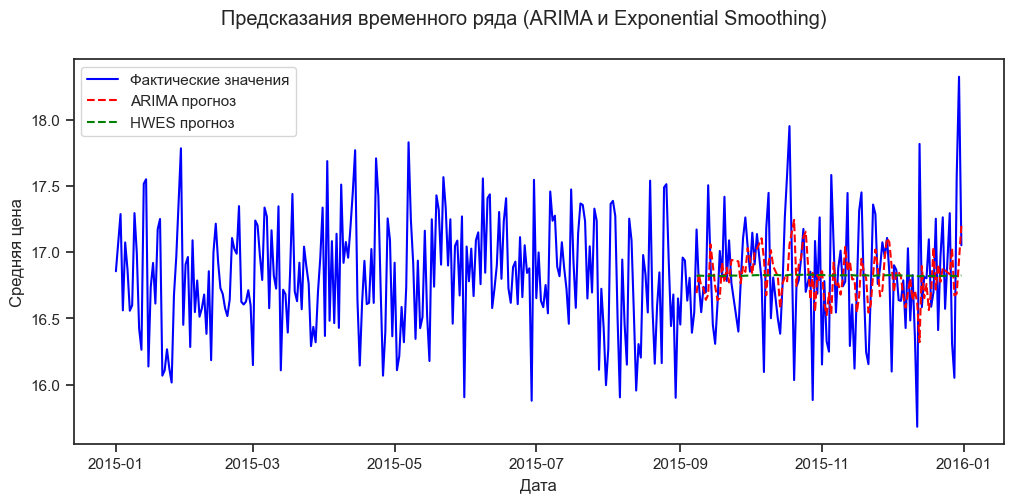

In [23]:
# График всего ряда с предсказаниями
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
fig.suptitle('Предсказания временного ряда (ARIMA и Exponential Smoothing)')
ax.plot(ts_fb2['Date'], ts_fb2['AveragePrice'], label='Фактические значения', color='blue')
ax.plot(ts_fb2['Date'], ts_fb2['predictions_ARIMA'], label='ARIMA прогноз', color='red', linestyle='--')
ax.plot(ts_fb2['Date'], ts_fb2['predictions_HWES'], label='HWES прогноз', color='green', linestyle='--')
ax.set_xlabel('Дата')
ax.set_ylabel('Средняя цена')
ax.legend()
plt.show()

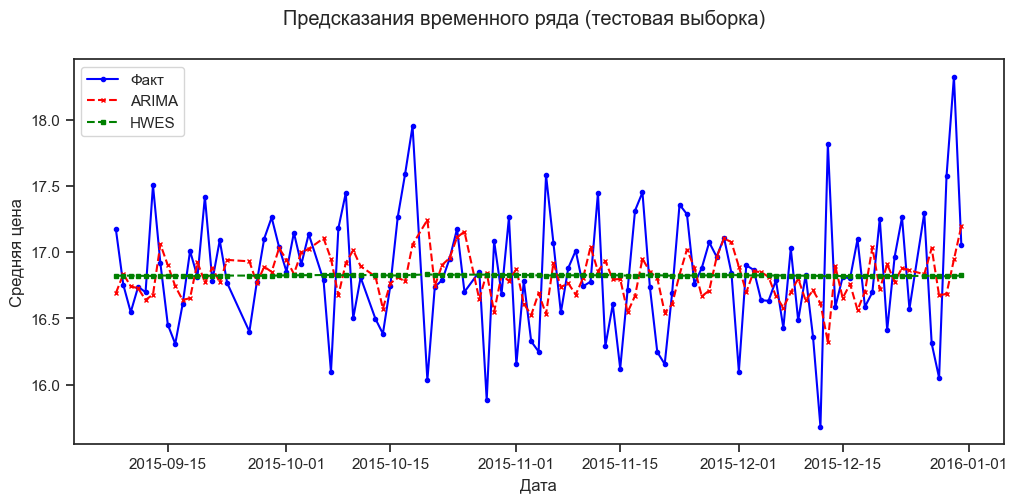

In [24]:
# График только тестовой выборки
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
fig.suptitle('Предсказания временного ряда (тестовая выборка)')
ax.plot(ts_fb2['Date'][train_size:], test, label='Факт', color='blue', marker='o', markersize=3)
ax.plot(ts_fb2['Date'][train_size:], predictions_arima, label='ARIMA', color='red', linestyle='--', marker='x', markersize=3)
ax.plot(ts_fb2['Date'][train_size:], predictions_es, label='HWES', color='green', linestyle='--', marker='s', markersize=3)
ax.set_xlabel('Дата')
ax.set_ylabel('Средняя цена')
ax.legend()
plt.show()

### 2) Метод символьной регрессии

In [25]:
from gplearn.genetic import SymbolicRegressor

In [68]:
# Определяем математические операции для символьной регрессии
function_set = ['add', 'sub', 'mul', 'div', 'sin', 'cos', 'sqrt', 'log']
# Создание и обучение модели символьной регрессии
est_gp = SymbolicRegressor(
    population_size=500,     
    generations=50,         
    stopping_criteria=0.1,    
    init_depth=(2, 4),        
    function_set=['add', 'sub', 'mul', 'div'], 
    const_range=(-1, 1),     
    p_crossover=0.8,
    p_subtree_mutation=0.1,
    p_hoist_mutation=0.05,
    p_point_mutation=0.05,
    parsimony_coefficient=0.01,  
    verbose=1,
    random_state=42
)

In [27]:
# Обучение модели
est_gp.fit(np.array(xnum_train).reshape(-1, 1), train.reshape(-1, 1))

C:\Users\mfnnx\anaconda3\envs\py38\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    17.27      3.87438e+11       15         0.896944              N/A      6.12s
   1    14.94          17874.6       17         0.407395              N/A      6.62s
   2    19.50          14708.7       17         0.407395              N/A      5.92s
   3    22.63           177459       15         0.430557              N/A      9.43s
   4    23.43          3667.93       11         0.410472              N/A      5.94s
   5    22.39          1980.55        9         0.406535              N/A      6.47s
   6    21.14          578.483        9         0.406535              N/A      5.64s
   7    15.13             1681       21         0.405719              N/A      5.84s
   8    11.12          25696.1       25         0.405859              N/A  

SymbolicRegressor(const_range=(-1, 1),
                  function_set=['add', 'sub', 'mul', 'div'], generations=50,
                  init_depth=(2, 4), p_crossover=0.8, p_hoist_mutation=0.05,
                  p_point_mutation=0.05, p_subtree_mutation=0.1,
                  parsimony_coefficient=0.01, population_size=500,
                  random_state=42, stopping_criteria=0.1, verbose=1)

In [28]:
print("Найденная математическая формула:")
print(est_gp._program)

Найденная математическая формула:
div(sub(0.290, div(X0, -0.075)), mul(0.790, X0))


In [29]:
# Прогнозирование на тестовой выборке
y_gp = est_gp.predict(np.array(xnum_test).reshape(-1, 1))
# Вывод первых 10 предсказаний
print("\nПервые 10 предсказаний:")
print(y_gp[:10])


Первые 10 предсказаний:
[16.77008455 16.77007871 16.77007291 16.77006716 16.77006146 16.7700558
 16.77005019 16.77004462 16.77003909 16.77003361]


In [30]:
# Оценка качества модели
mae_gp = mean_absolute_error(test, y_gp)
rmse_gp = np.sqrt(mean_squared_error(test, y_gp))
print(f"\nСимвольная регрессия - MAE: {mae_gp:.2f}, RMSE: {rmse_gp:.2f}")


Символьная регрессия - MAE: 0.34, RMSE: 0.45


In [31]:
# Записываем предсказания в DataFrame
ts_fb2['predictions_GPLEARN'] = (train_size * [np.NAN]) + list(y_gp)

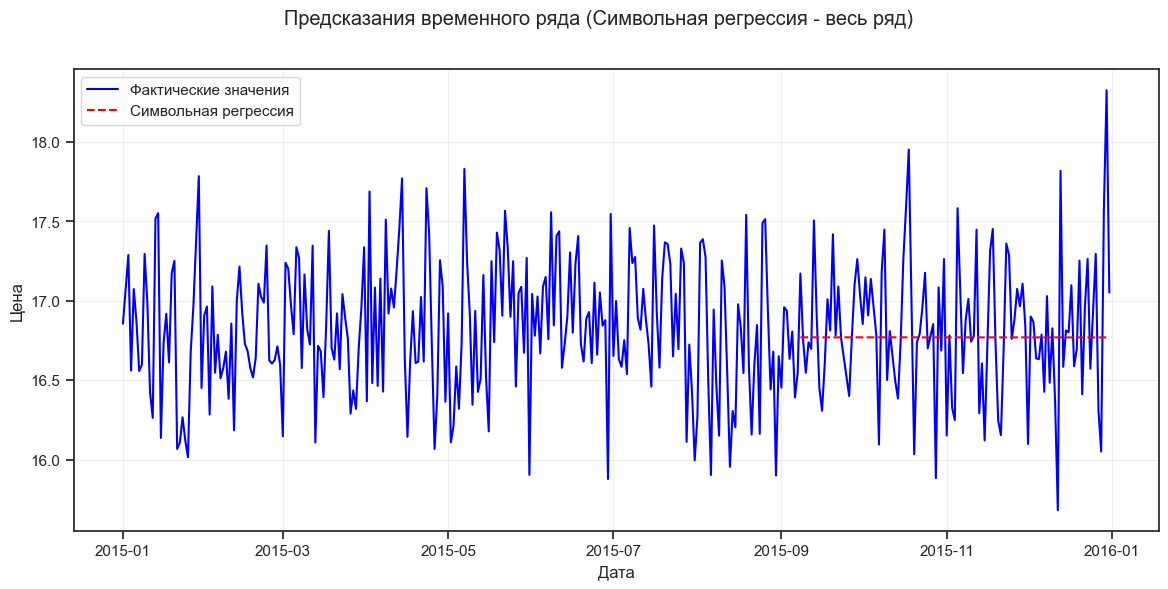

In [32]:
# Полный график с предсказаниями
fig, ax = plt.subplots(1, 1, figsize=(14, 6))
fig.suptitle('Предсказания временного ряда (Символьная регрессия - весь ряд)')
ax.plot(ts_fb2['Date'], ts_fb2['AveragePrice'], label='Фактические значения', color='blue')
ax.plot(ts_fb2['Date'], ts_fb2['predictions_GPLEARN'], label='Символьная регрессия', color='red', linestyle='--')
ax.set_xlabel('Дата')
ax.set_ylabel('Цена')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

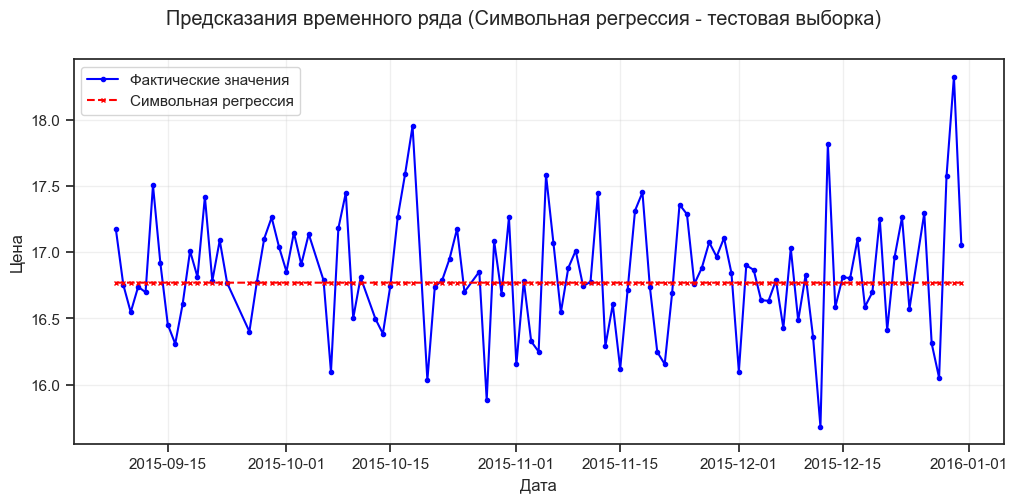

In [33]:
# Визуализация результатов
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
fig.suptitle('Предсказания временного ряда (Символьная регрессия - тестовая выборка)')
ax.plot(ts_fb2['Date'][train_size:], test, label='Фактические значения', color='blue', marker='o', markersize=3)
ax.plot(ts_fb2['Date'][train_size:], y_gp, label='Символьная регрессия', color='red', linestyle='--', marker='x', markersize=3)
ax.set_xlabel('Дата')
ax.set_ylabel('Цена')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

### 3) Семейство МГУА (COMBI и RIA)

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from gmdh import Combi, Ria, time_series_transformation, split_data

In [56]:
# Подготовка данных
data = ts_fb2['AveragePrice'].values
lags = 7
# Создаем матрицу X (признаки) и y (целевая переменная)
X, y = time_series_transformation(data, lags=lags)
print(f"Исходные данные: {len(data)} точек")
print(f"После создания лагов: X shape {X.shape}, y shape {y.shape}")

Исходные данные: 358 точек
После создания лагов: X shape (351, 7), y shape (351,)


In [57]:
# Разделение на обучающую и тестовую выборки
train_size = int(len(X) * 0.7)
x_train, x_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
print(f"x_train: {x_train.shape}, x_test: {x_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

x_train: (245, 7), x_test: (106, 7)
y_train: (245,), y_test: (106,)


In [58]:
# Модель COMBI
print("\n" + "="*50)
print("Обучение COMBI...")
print("="*50)
model_combi = Combi()
model_combi.fit(x_train, y_train)
y_pred_combi = model_combi.predict(x_test)


Обучение COMBI...


In [59]:
# Модель RIA
print("\n" + "="*50)
print("Обучение RIA...")
print("="*50)
model_ria = Ria()
model_ria.fit(x_train, y_train)
y_pred_ria = model_ria.predict(x_test)


Обучение RIA...


In [60]:
# Оценка качества
mae_combi = mean_absolute_error(y_test, y_pred_combi)
rmse_combi = np.sqrt(mean_squared_error(y_test, y_pred_combi))
mae_ria = mean_absolute_error(y_test, y_pred_ria)
rmse_ria = np.sqrt(mean_squared_error(y_test, y_pred_ria))
print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ")
print("="*50)
print(f"COMBI - MAE: {mae_combi:.2f}, RMSE: {rmse_combi:.2f}")
print(f"RIA   - MAE: {mae_ria:.2f}, RMSE: {rmse_ria:.2f}")


РЕЗУЛЬТАТЫ
COMBI - MAE: 0.34, RMSE: 0.45
RIA   - MAE: 0.34, RMSE: 0.45



Длина test_dates: 106
Длина y_test: 106
Длина y_pred_combi: 106


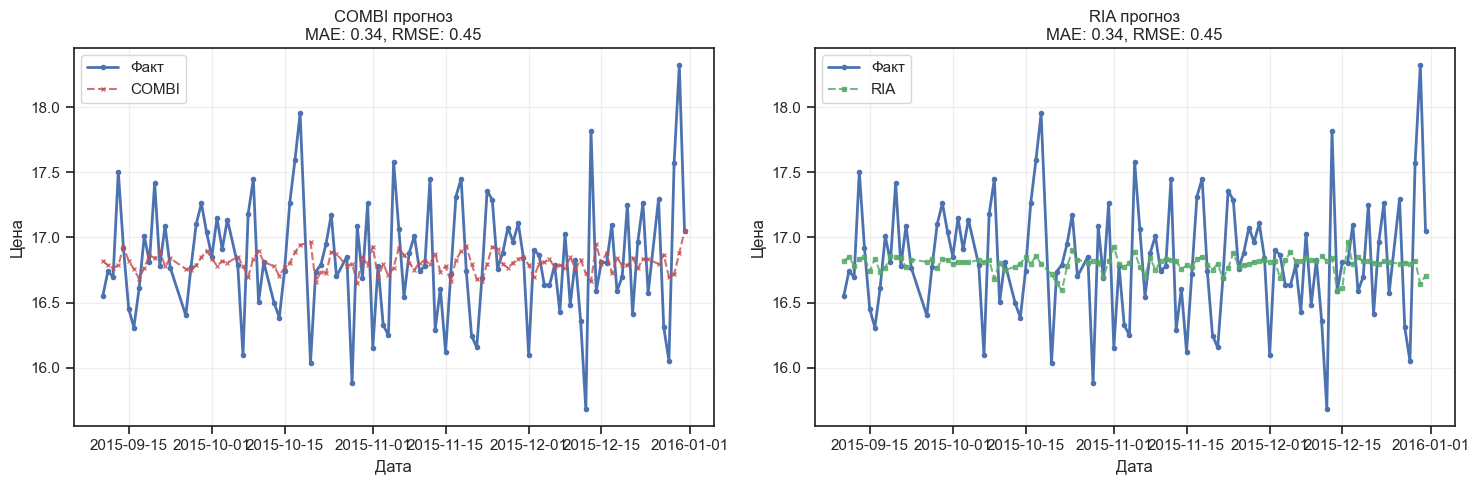

In [61]:
# Визуализация (исправлено: берем правильное количество дат)
# Датасет сдвигается на количество лагов
test_dates = ts_fb2['Date'].iloc[train_size + lags:train_size + lags + len(y_test)]

print(f"\nДлина test_dates: {len(test_dates)}")
print(f"Длина y_test: {len(y_test)}")
print(f"Длина y_pred_combi: {len(y_pred_combi)}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# График COMBI
axes[0].plot(test_dates, y_test, 'b-', label='Факт', linewidth=2, marker='o', markersize=3)
axes[0].plot(test_dates, y_pred_combi, 'r--', label='COMBI', alpha=0.8, marker='x', markersize=3)
axes[0].set_title(f'COMBI прогноз\nMAE: {mae_combi:.2f}, RMSE: {rmse_combi:.2f}')
axes[0].set_xlabel('Дата')
axes[0].set_ylabel('Цена')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График RIA
axes[1].plot(test_dates, y_test, 'b-', label='Факт', linewidth=2, marker='o', markersize=3)
axes[1].plot(test_dates, y_pred_ria, 'g--', label='RIA', alpha=0.8, marker='s', markersize=3)
axes[1].set_title(f'RIA прогноз\nMAE: {mae_ria:.2f}, RMSE: {rmse_ria:.2f}')
axes[1].set_xlabel('Дата')
axes[1].set_ylabel('Цена')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Оценка качества прогноза

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Функция для расчета MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Функция для оценки моделей
def evaluate_model(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    return {
        'Модель': name,
        'MAE': f'{mae:.3f}',
        'RMSE': f'{rmse:.3f}',
        'MAPE (%)': f'{mape:.2f}'
    }

# Создаем список с моделями и их предсказаниями
models_to_compare = [
    ('ARIMA', predictions_arima),
    ('HWES (Exponential Smoothing)', predictions_es),
    ('GPLEARN (Symbolic Regression)', y_gp),
    ('COMBI (GMDH)', y_pred_combi),
    ('RIA (GMDH)', y_pred_ria)
]

# Убеждаемся, что все предсказания имеют одинаковую длину с y_test
print(f"Длина y_test: {len(y_test)}")
for name, pred in models_to_compare:
    if len(pred) > len(y_test):
        pred = pred[:len(y_test)]
    print(f"Длина {name}: {len(pred)}")

Длина y_test: 106
Длина ARIMA: 106
Длина HWES (Exponential Smoothing): 106
Длина GPLEARN (Symbolic Regression): 106
Длина COMBI (GMDH): 106
Длина RIA (GMDH): 106


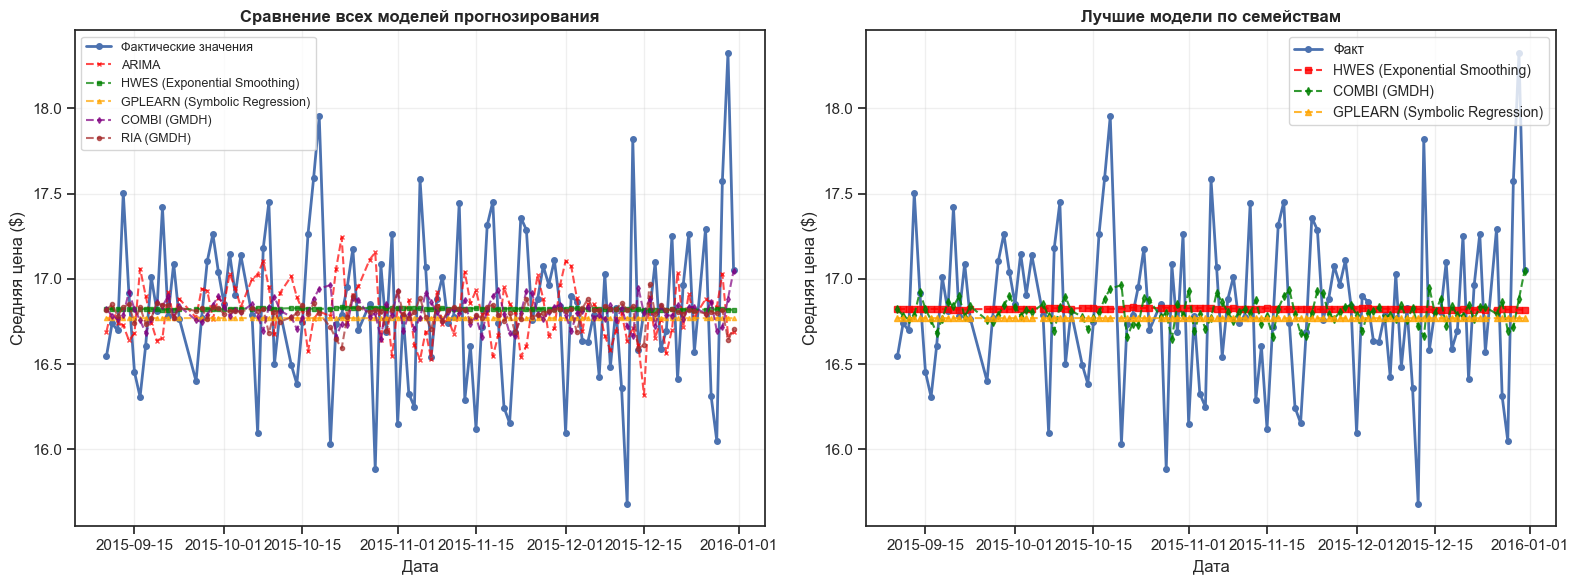

In [70]:
# Создаем фигуру с двумя подграфиками
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Используем те же даты, что и ранее
test_dates = ts_fb2['Date'].iloc[train_size + lags:train_size + lags + len(y_test)]

# График 1: Все модели
ax1.plot(test_dates, y_test, 'b-', label='Фактические значения', linewidth=2, marker='o', markersize=4)

colors = ['red', 'green', 'orange', 'purple', 'brown']
markers = ['x', 's', '^', 'd', 'o']

for (name, pred), color, marker in zip(models_to_compare, colors, markers):
    if len(pred) > len(y_test):
        pred = pred[:len(y_test)]
    ax1.plot(test_dates, pred, '--', color=color, label=name, 
             alpha=0.7, marker=marker, markersize=3, linewidth=1.5)

ax1.set_title('Сравнение всех моделей прогнозирования', fontsize=12, fontweight='bold')
ax1.set_xlabel('Дата')
ax1.set_ylabel('Средняя цена ($)')
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)

# График 2: Только лучшие модели (сгруппируем по семействам)
# Выберем лучшую из ARIMA/HWES, лучшую из GMDH и GPLEARN
best_arima_es = models_to_compare[1]  # HWES показал лучший RMSE среди ARIMA/HWES
best_gmdh = models_to_compare[3]       # COMBI
best_symbolic = models_to_compare[2]   # GPLEARN

ax2.plot(test_dates, y_test, 'b-', label='Факт', linewidth=2, marker='o', markersize=4)

for (name, pred), color, marker in zip([best_arima_es, best_gmdh, best_symbolic], 
                                        ['red', 'green', 'orange'], 
                                        ['s', 'd', '^']):
    if len(pred) > len(y_test):
        pred = pred[:len(y_test)]
    ax2.plot(test_dates, pred, '--', color=color, label=name, 
             alpha=0.8, marker=marker, markersize=4, linewidth=1.5)

ax2.set_title('Лучшие модели по семействам', fontsize=12, fontweight='bold')
ax2.set_xlabel('Дата')
ax2.set_ylabel('Средняя цена ($)')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [71]:
# Собираем результаты для всех моделей
all_results = []

for name, pred in models_to_compare:
    # Приводим к одинаковой длине
    if len(pred) > len(y_test):
        pred_eval = pred[:len(y_test)]
    else:
        pred_eval = pred
    
    mae = mean_absolute_error(y_test, pred_eval)
    rmse = np.sqrt(mean_squared_error(y_test, pred_eval))
    mape = mean_absolute_percentage_error(y_test, pred_eval)
    
    all_results.append({
        'Модель': name,
        'MAE': f'{mae:.3f}',
        'RMSE': f'{rmse:.3f}',
        'MAPE (%)': f'{mape:.2f}'
    })

# Создаем DataFrame и сортируем по RMSE
results_df = pd.DataFrame(all_results)
results_df['RMSE_num'] = results_df['RMSE'].astype(float)
results_df = results_df.sort_values('RMSE_num').drop('RMSE_num', axis=1)

print("=" * 80)
print("СРАВНИТЕЛЬНАЯ ТАБЛИЦА КАЧЕСТВА ПРОГНОЗОВ")
print("=" * 80)
print(results_df.to_string(index=False))

# Находим абсолютного победителя
best_model = results_df.iloc[0]['Модель']
best_rmse = results_df.iloc[0]['RMSE']

print("\n" + "=" * 80)
print(f"ЛУЧШАЯ МОДЕЛЬ: {best_model}")
print(f"   - MAE: {results_df.iloc[0]['MAE']}")
print(f"   - RMSE: {best_rmse}")
print(f"   - MAPE: {results_df.iloc[0]['MAPE (%)']}%")
print("=" * 80)

# Выводим ранжирование моделей
print("\nРАНЖИРОВАНИЕ МОДЕЛЕЙ (по RMSE):")
for i, row in results_df.iterrows():
    print(f"{i+1}. {row['Модель']}: RMSE={row['RMSE']}, MAE={row['MAE']}, MAPE={row['MAPE (%)']}%")

СРАВНИТЕЛЬНАЯ ТАБЛИЦА КАЧЕСТВА ПРОГНОЗОВ
                       Модель   MAE  RMSE MAPE (%)
                 COMBI (GMDH) 0.342 0.445     2.03
 HWES (Exponential Smoothing) 0.339 0.446     2.01
GPLEARN (Symbolic Regression) 0.340 0.450     2.01
                   RIA (GMDH) 0.341 0.450     2.02
                        ARIMA 0.391 0.508     2.32

ЛУЧШАЯ МОДЕЛЬ: COMBI (GMDH)
   - MAE: 0.342
   - RMSE: 0.445
   - MAPE: 2.03%

РАНЖИРОВАНИЕ МОДЕЛЕЙ (по RMSE):
4. COMBI (GMDH): RMSE=0.445, MAE=0.342, MAPE=2.03%
2. HWES (Exponential Smoothing): RMSE=0.446, MAE=0.339, MAPE=2.01%
3. GPLEARN (Symbolic Regression): RMSE=0.450, MAE=0.340, MAPE=2.01%
5. RIA (GMDH): RMSE=0.450, MAE=0.341, MAPE=2.02%
1. ARIMA: RMSE=0.508, MAE=0.391, MAPE=2.32%
